In [255]:
# read data from csv
data = {"exp": [], "sal": [], "loan": []}
for line in open("loan.csv"):
    if line.startswith("Experience"):
        continue
    point = line.strip().split(",")
    data["exp"].append(float(point[0]))
    data["sal"].append(float(point[1]))
    data["loan"].append(float(point[2]))

size = len(data["exp"])
x_train = list((x1, x2) for x1, x2 in zip(data["exp"], data["sal"]))
y_train = data["loan"]

print(x_train)
print((y_train, size))

[(3.0, 4.0), (2.5, 4.0), (1.0, 4.0), (2.5, 5.0), (2.0, 5.0), (1.5, 5.0), (0.5, 5.0), (1.75, 6.0), (0.25, 6.0), (1.0, 7.0), (0.25, 7.0), (0.2, 7.0), (0.15, 7.0), (2.0, 8.0), (1.0, 8.0), (0.15, 8.0), (0.1, 8.0), (0.5, 9.0), (1.0, 10.0)]
([1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0], 19)


In [ ]:
import math


def predict(x, w) -> float:
    x_with_bias = [1.0] + list(x)
    return sum((w_i * x_i for w_i, x_i in zip(w, x_with_bias)))


def sigmoid(z) -> float:
    return 1 / (1 + math.exp(-z))


def loss(x, y, w) -> float:
    y_pred = [predict(x_i, w) for x_i in x]
    return (
        sum(
            math.log(1 + math.exp(y_pred_i)) - y_i * y_pred_i
            for y_i, y_pred_i in zip(y, y_pred)
        )
        / size
    )


def grad_descent(x, y, w, lr):
    y_pred = [predict(x_i, w) for x_i in x]
    x = [[1.0] + list(x_i) for x_i in x]
    new_w = []
    for j, w_j in enumerate(w):
        w_j = w_j - (
            lr
            * sum(
                x_i[j] * (1 - y_i - sigmoid(-y_pred_i)) for x_i, y_i, y_pred_i in zip(x, y, y_pred)
            )
            / size
        )
        new_w.append(w_j)
    return new_w


def training_loop(weight, lr, epsilon):
    time = 0
    current_loss = loss(x_train, y_train, weight)
    # print("initial loss", current_loss)
    delta = 10

    while delta > epsilon:
        weight = grad_descent(x_train, y_train, weight, lr)
        new_loss = loss(x_train, y_train, weight)
        delta = current_loss - new_loss
        current_loss = new_loss
        # print(time, weight, current_loss, delta)

        time += 1
    return time, weight, current_loss

In [257]:
lr = 1 * 1e-4
weight = (0.0, -1.0, 1.0)
epsilon = 1e-6

time, weight, final_loss = training_loop(weight, lr, epsilon)


def prettify(num):
    if isinstance(num, tuple):
        return tuple(prettify(n) for n in num)
    return round(num, 4)
    

print(
    f"Converged in {prettify(time)} iterations with final weight {tuple(map(prettify, weight))} and loss {prettify(final_loss)}"
)

initial loss 3.1925879490434257
Converged in 81638 iterations with final weight (-0.2353, 0.9585, -0.1156) and loss 0.4979


[0.8982244709930732, 0.845328485445689, 0.5648171595108123, 0.8296035372775891, 0.7509324278006001, 0.6512101500864343, 0.4172447162032048, 0.6788246266471839, 0.33418650036788683, 0.4784960089763991, 0.3089757763699608, 0.29883851893012353, 0.2888948096688075, 0.6806556590334272, 0.4497525170112524, 0.2657371625739006, 0.25649197024009746, 0.3107745022356431, 0.39344027618715754]


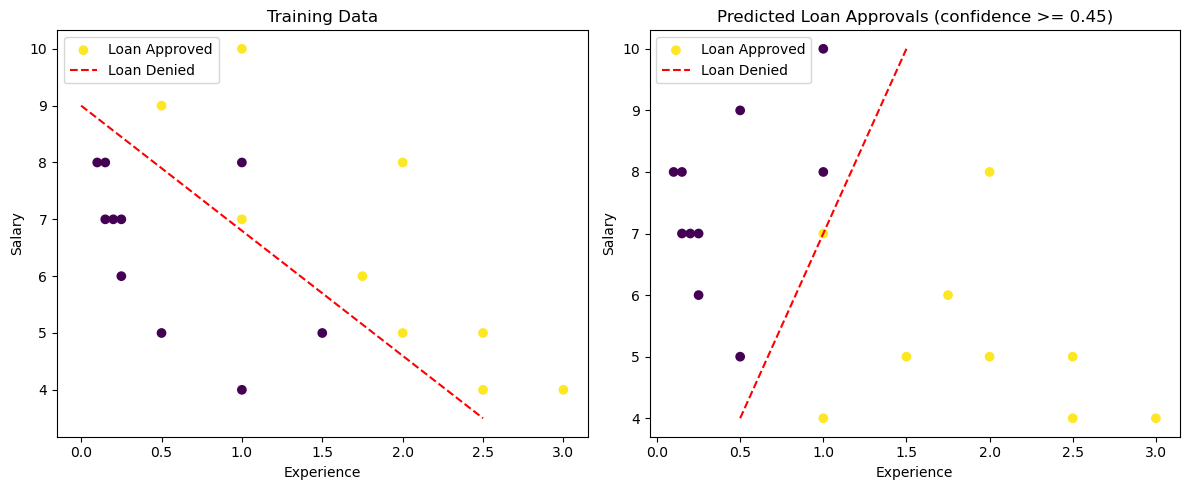

In [258]:
import matplotlib.pyplot as plt

confidence = 0.45

y_pred = [sigmoid(predict(x_i, weight)) for x_i in x_train]
print(y_pred)
loan_pred = [1 if y_p >= confidence else 0 for y_p in y_pred]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(data["exp"],data["sal"], c=data["loan"], cmap="viridis")
plt.plot([0, 2.5], [9, 3.5], color="red", linestyle="--")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Training Data")
plt.legend(["Loan Approved", "Loan Denied"], loc="upper left")

plt.subplot(1, 2, 2)
plt.scatter(data["exp"], data["sal"], c=loan_pred, cmap="viridis")
plt.plot([0.5, 1.5], [4, 10], color="red", linestyle="--")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title(f"Predicted Loan Approvals (confidence >= {confidence})")
plt.legend(["Loan Approved", "Loan Denied"], loc="upper left")
plt.tight_layout()
plt.show()

initial loss 3.1925879490434257
Converged in 1 iterations with final weight [-4.9000547048021235e-09, -1.000000001800526, 0.9999999673649538] and loss 3.1925878398135588
initial loss 3.1925879490434257
Converged in 503062 iterations with final weight [-0.023959207652998877, -1.0074882942914876, 0.8389756663824777] and loss 2.664541045776385
initial loss 3.1925879490434257
Converged in 337717 iterations with final weight [-0.10580851200513565, -0.9567825727317261, 0.2236552818803324] and loss 1.1653074115145101
initial loss 3.1925879490434257
Converged in 270094 iterations with final weight [-0.0955953825827895, -0.46779831066119887, 0.06846999440065114] and loss 0.8742157302229495
initial loss 3.1925879490434257
Converged in 264020 iterations with final weight [-0.09054942314081721, 0.01674582103896774, -0.0017255032431684285] and loss 0.6864275465847163
initial loss 3.1925879490434257
Converged in 119747 iterations with final weight [-0.16057369086295545, 0.713341849237663, -0.0927956

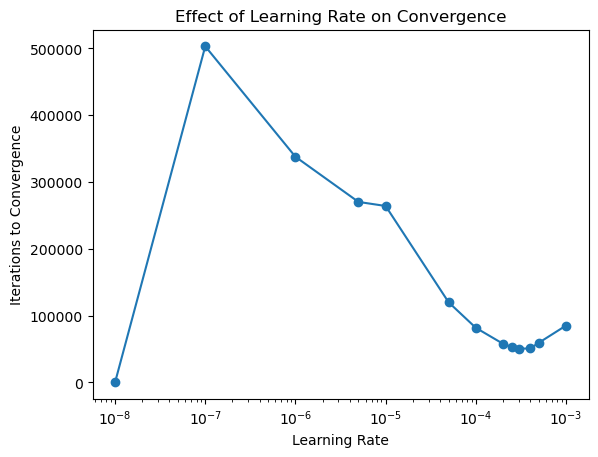

In [253]:
lrs = [1e-8, 1e-7,1e-6, 5 * 1e-6, 1e-5, 5 * 1e-5, 1e-4, 2 * 1e-4, 2.5 * 1e-4, 3 * 1e-4, 4 * 1e-4, 5 * 1e-4, 1e-3]

epsilon = 1e-6
data = []
for lr in lrs:
    weight = (0.0, -1.0, 1.0)
    time, weight, final_loss = training_loop(weight, lr, epsilon)
    print(
        f"Converged in {time} iterations with final weight {weight} and loss {final_loss}"
    )
    data.append((lr, time))

plt.plot([d[0] for d in data], [d[1] for d in data], marker="o")
plt.xlabel("Learning Rate")
plt.ylabel("Iterations to Convergence")
plt.title("Effect of Learning Rate on Convergence")
plt.xscale("log")
plt.show()